In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pgeocode
import shap
import joblib
import geopandas as gpd
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [65]:
sold = pd.read_csv("C:/Users/44756/Documents/Postgrad/DSA8030/Data/sold_treated.csv", dtype = {'brokered_by':'string', 'street':'string', 'zip_code':'string'}, parse_dates = ['prev_sold_date'])
nomi = pgeocode.Nominatim('us')
location_data = nomi.query_postal_code(sold['zip_code'].tolist())
sold['latzip'] = location_data['latitude'].values
sold['longzip'] = location_data['longitude'].values
sold_dummy = pd.get_dummies(sold['state']).astype('int')
sold = pd.concat([sold, sold_dummy], axis = 1)
sold['cityfreq'] = sold['city'].map(sold['city'].value_counts())
sold['streetfreq'] = sold['street'].map(sold['street'].value_counts())
sold['brokerfreq'] = sold['brokered_by'].map(sold['brokered_by'].value_counts())
sold['otherstate_xgb'] = sold['state'].isin(['Vermont', 'Indiana', 'North Dakota', 'New Mexico', 'New Hampshire', 'Minnesota', 'Maine', 'Delaware', 'Alabama', 'Wyoming']).astype('int')
sold_train, sold_test = train_test_split(sold, test_size = 0.2, random_state=1)

In [66]:
model_rf = joblib.load("C:/Users/44756/Documents/Postgrad/DSA8030/model_rf.joblib")
model_xgb = joblib.load("C:/Users/44756/Documents/Postgrad/DSA8030/model_xgb.joblib")

In [131]:
def plt_pricepred(var, ax_lab, bin_no = 10, leg_pos = 'upper right'):
    # D shoreline price/pred univariate
    fig, ax = plt.subplots()

    hist = ax.hist(sold_xgb[var], ec = 'black', bins = bin_no)
    midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
    prices = [sold_xgb[(sold_xgb[var] >= hist[1][x]) & (sold_xgb[var] < hist[1][x+1])].price.median() for x in range(len(hist[1])-1)]
    preds = [sold_xgb[(sold_xgb[var] >= hist[1][x]) & (sold_xgb[var] < hist[1][x+1])].pred.median() for x in range(len(hist[1])-1)]
    ax.set_xlabel(ax_lab)
    ax.set_ylabel('Frequency')
    ax2 = ax.twinx()
    ax2.plot(midpts, prices, color = 'orange')
    ax2.scatter(midpts, prices, color = 'orange', label = 'Actual')
    ax2.plot(midpts, preds, color = 'red')
    ax2.scatter(midpts, preds, color = 'red', label = 'Prediction', marker = 's')
    ax2.set_ylabel('Median Price ($)')
    ax2.legend(loc = leg_pos)
    plt.show()

XGBoost

R^2 0.8487504865240199
RMSE 190508.45662234596
MAE 93075.18329855861
Positive residuals: 74782
Negative residuals: 86242
Average positive residual: 45768.890625
Average negative residual: -50311.046875
Average percentage error: 14.604585598468937


Text(0, 0.5, 'Predicted')

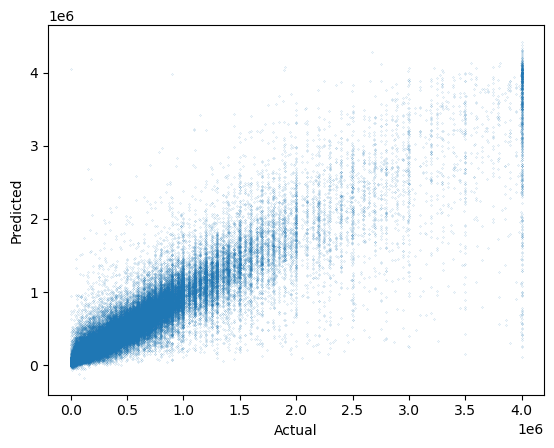

In [225]:
xgb_x = sold_test[['bed', 'bath', 'acre_lot', 'house_size', 'latzip', 'longzip', 'cityfreq', 'streetfreq', 'brokerfreq', 'precipitation', 'maxtemp', 'avgtemp', 'po_box', 'population', 'density', 'dhighway', 'dlairport', 'dmairport', 'dshore', 'nobusiness', 'totalincome', 'tax_returns','Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Jersey', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'otherstate_xgb']]
xgb_y = sold_test['price']
xgb_pred = model_xgb.predict(xgb_x)

resids_xgb = xgb_y - xgb_pred
percenterror_xgb = (xgb_y - xgb_pred) / xgb_y
print('R^2', model_xgb.score(xgb_x, xgb_y))
print('RMSE', root_mean_squared_error(xgb_y, xgb_pred))
print('MAE', mean_absolute_error(xgb_y, xgb_pred))
print('Positive residuals:', len(resids_xgb[resids_xgb > 0]))
print('Negative residuals:', len(resids_xgb[resids_xgb < 0]))
print('Average positive residual:', np.median(resids_xgb[resids_xgb > 0]))
print('Average negative residual:', np.median(resids_xgb[resids_xgb < 0]))
print('Average percentage error:', np.median(abs(percenterror_xgb)) * 100)
plt.scatter(xgb_y, xgb_pred, s = 0.01)
plt.xlabel('Actual')
plt.ylabel('Predicted')

In [68]:
sold_xgb = sold_test.copy()
sold_xgb['pred'] = xgb_pred.tolist()

In [44]:
explainer_xgb = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(xgb_x)

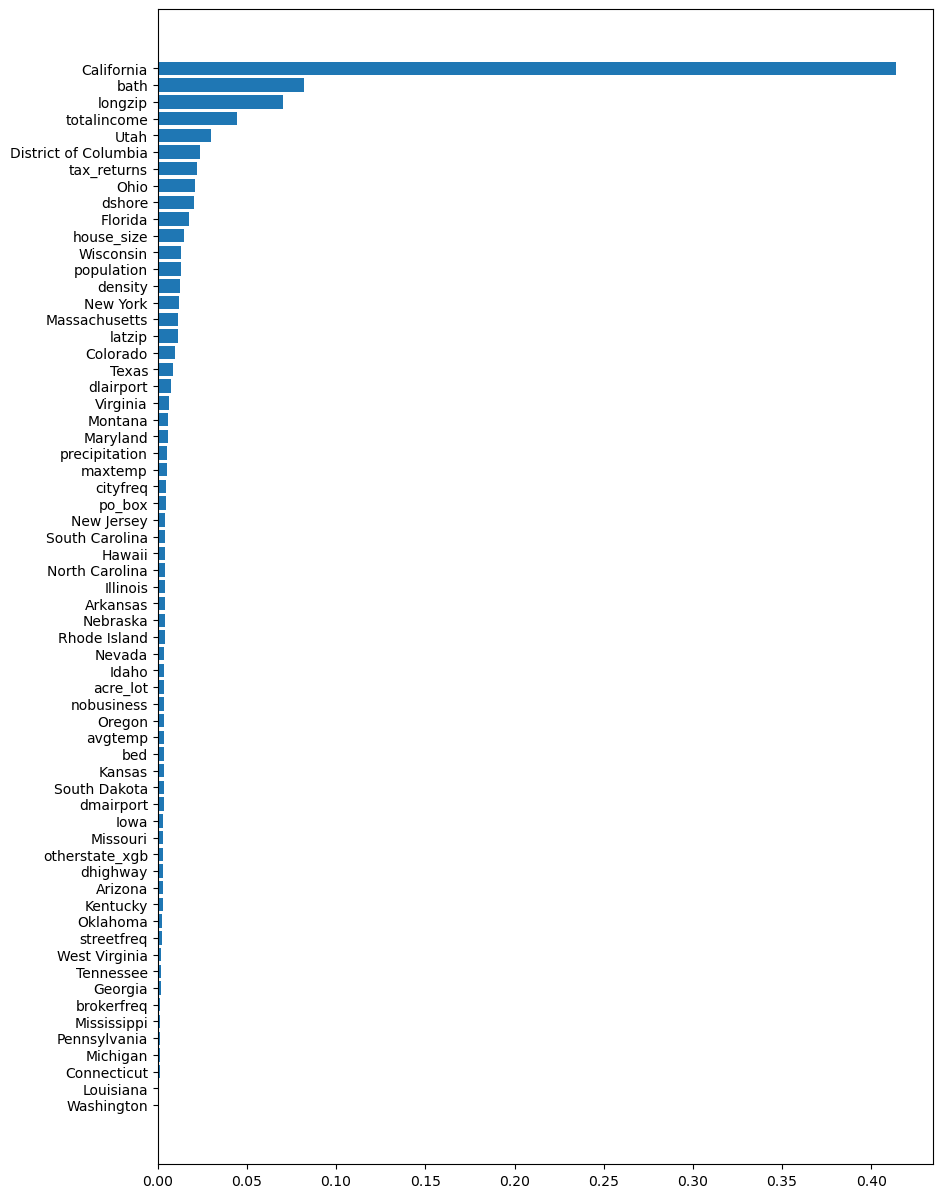

In [48]:
sorted_idx = model_xgb.feature_importances_.argsort()
plt.figure(figsize=(10,15))
plt.barh(model_xgb.feature_names_in_[sorted_idx], model_xgb.feature_importances_[sorted_idx])
plt.show()

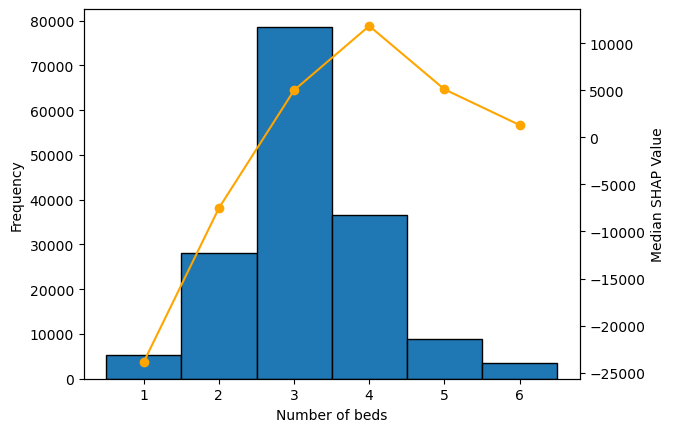

In [8]:
# Bed univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.bed, ec = 'black', bins = np.arange(0.5,7.5))
shaps = [np.median(shap_values_xgb[xgb_x.bed == x, 0]) for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of beds')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), shaps, color = 'orange')
ax2.scatter(np.arange(1,7), shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

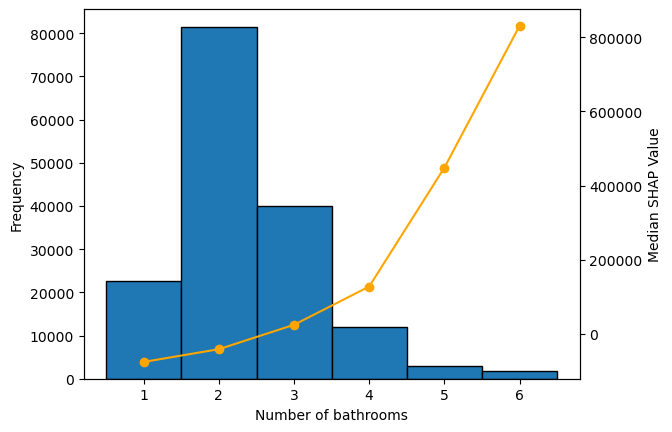

In [9]:
# Bath univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.bath, ec = 'black', bins = np.arange(0.5,7.5))
shaps = [np.median(shap_values_xgb[xgb_x.bath == x, 1]) for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of bathrooms')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), shaps, color = 'orange')
ax2.scatter(np.arange(1,7), shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

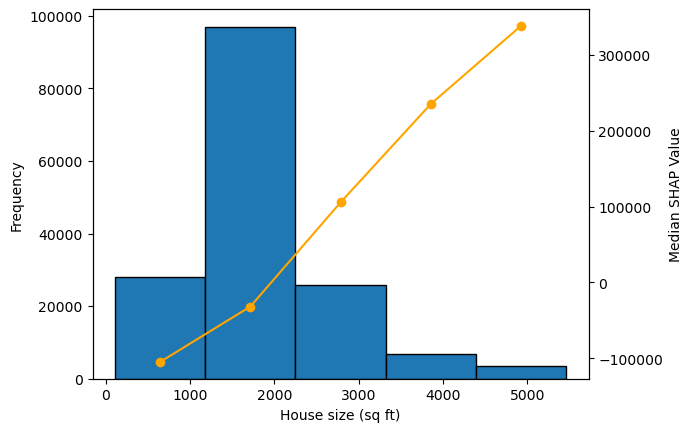

In [10]:
# House size univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.house_size, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.house_size >= hist[1][x]) & (xgb_x.house_size < hist[1][x+1]), 3]) for x in range(len(hist[1])-1)]
ax.set_xlabel('House size (sq ft)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

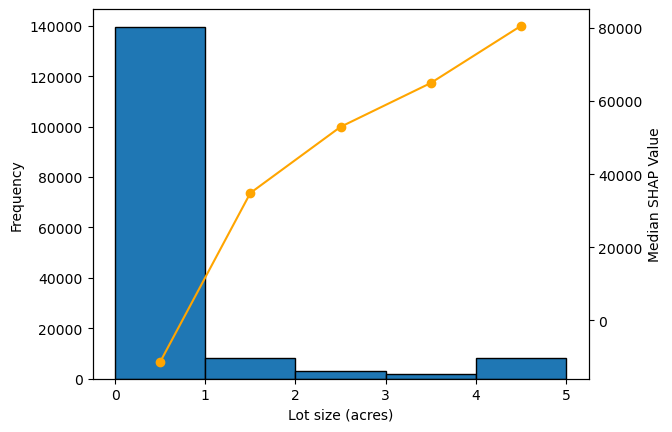

In [11]:
# Acre lot univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.acre_lot, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.acre_lot >= hist[1][x]) & (xgb_x.acre_lot < hist[1][x+1]), 2]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Lot size (acres)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

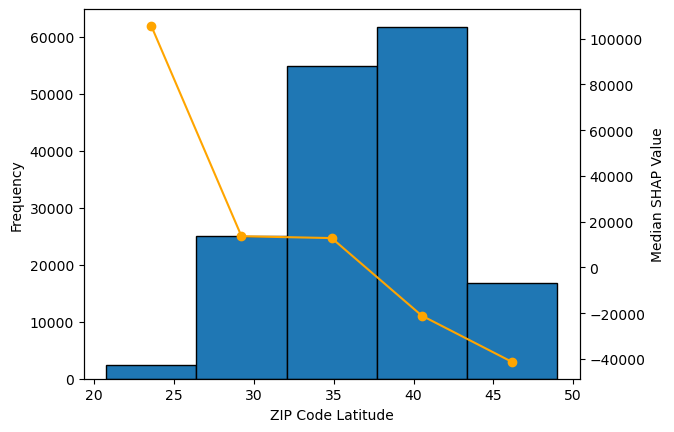

In [12]:
# ZIP latitude univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.latzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.latzip >= hist[1][x]) & (xgb_x.latzip < hist[1][x+1]), 4]) for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Latitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

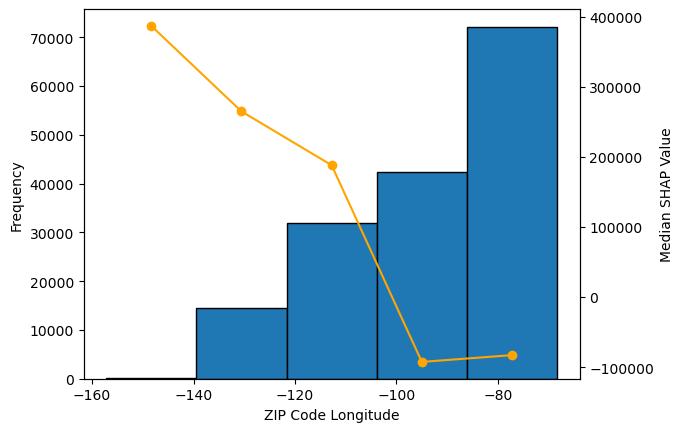

In [13]:
# ZIP longitude univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.longzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.longzip >= hist[1][x]) & (xgb_x.longzip < hist[1][x+1]), 5]) for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Longitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

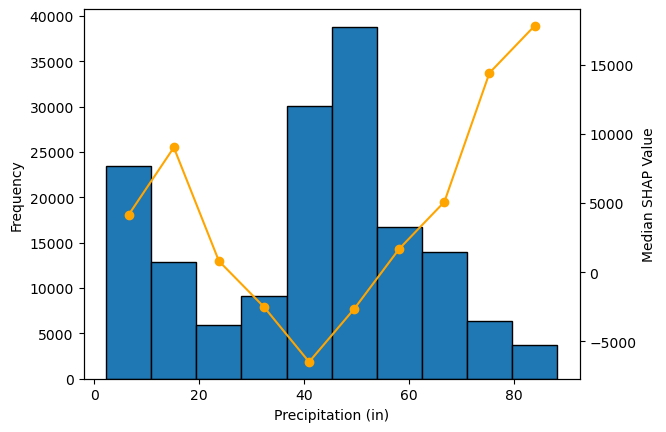

In [39]:
# Precipitation univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.precipitation, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.precipitation >= hist[1][x]) & (xgb_x.precipitation < hist[1][x+1]), 9]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Precipitation (in)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

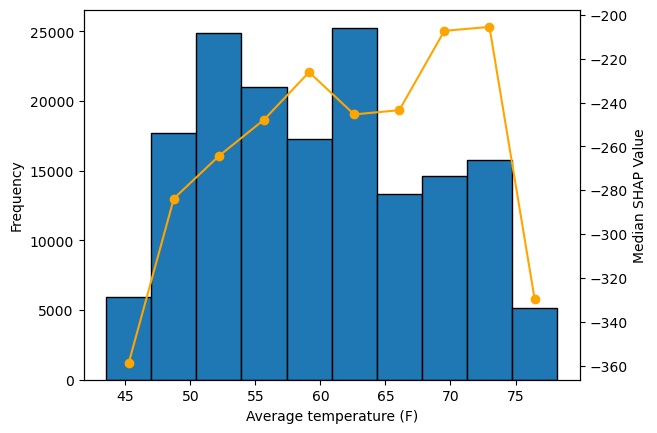

In [15]:
# Avg temp univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.avgtemp, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.avgtemp >= hist[1][x]) & (xgb_x.avgtemp < hist[1][x+1]), 12]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Average temperature (F)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

In [17]:
# # Min temp univariate
# fig, ax = plt.subplots()

# hist = ax.hist(xgb_x.mintemp, ec = 'black')
# midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
# shaps = [np.median(shap_values_xgb[(xgb_x.mintemp >= hist[1][x]) & (xgb_x.mintemp < hist[1][x+1]), 11]) for x in range(len(hist[1])-1)]
# ax.set_xlabel('Minimum temperature (F)')
# ax.set_ylabel('Frequency')
# ax2 = ax.twinx()
# ax2.plot(midpts, shaps, color = 'orange')
# ax2.scatter(midpts, shaps, color = 'orange')
# ax2.set_ylabel('Median SHAP Value')
# plt.show()

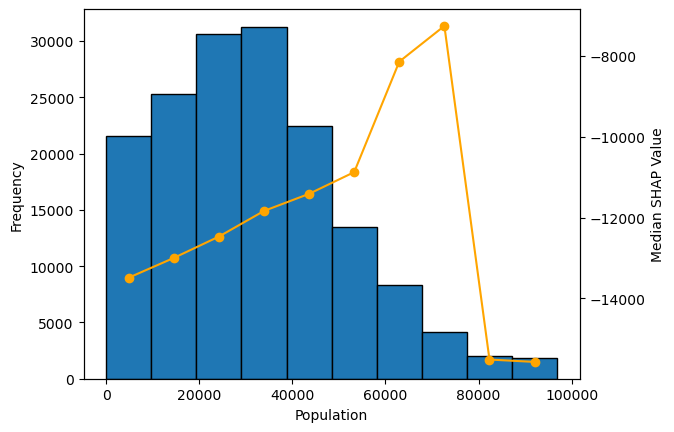

In [18]:
# Population univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.population, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.population >= hist[1][x]) & (xgb_x.population < hist[1][x+1]), 14]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Population')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

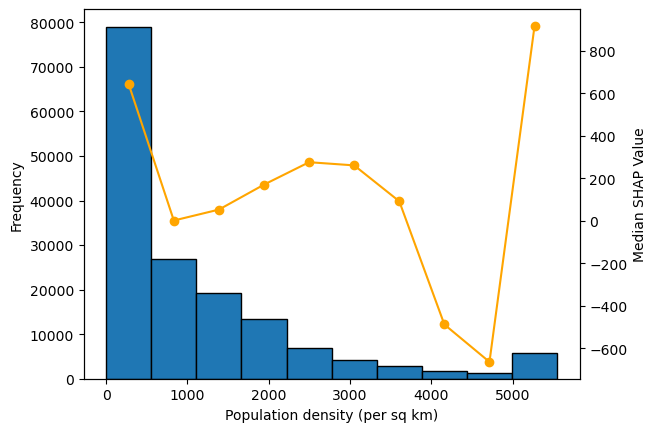

In [19]:
# Population density univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.density, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.density >= hist[1][x]) & (xgb_x.density < hist[1][x+1]), 15]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Population density (per sq km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

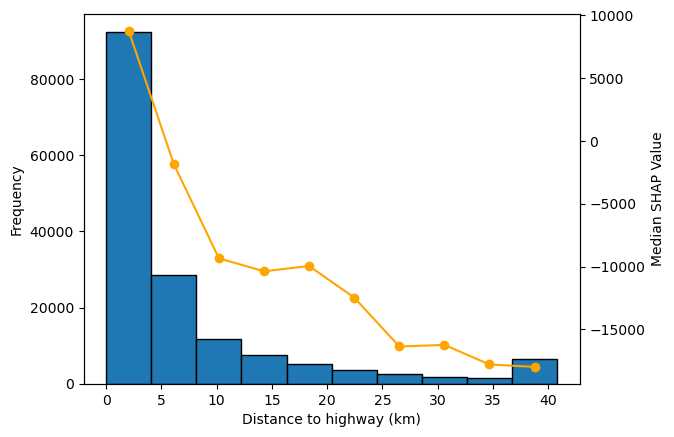

In [20]:
# Distance to highway univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dhighway, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dhighway >= hist[1][x]) & (xgb_x.dhighway < hist[1][x+1]), 16]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to highway (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

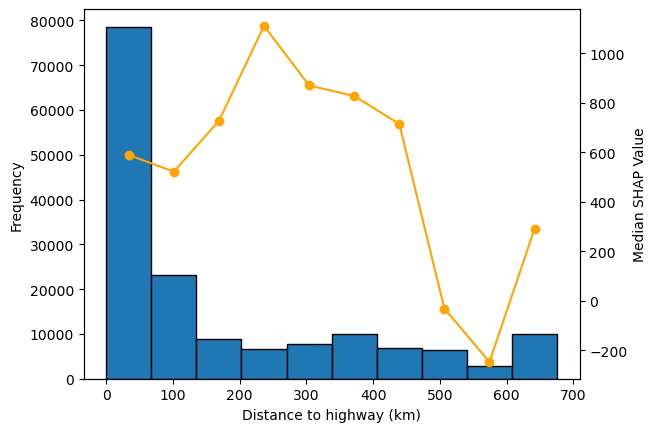

In [21]:
# Distance to shoreline univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dshore, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dshore >= hist[1][x]) & (xgb_x.dshore < hist[1][x+1]), 19]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to highway (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

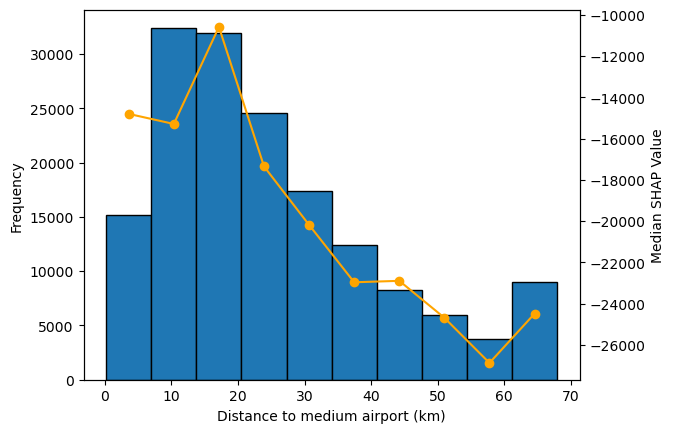

In [22]:
# Distance to medium airport univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dmairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dmairport >= hist[1][x]) & (xgb_x.dmairport < hist[1][x+1]), 18]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to medium airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

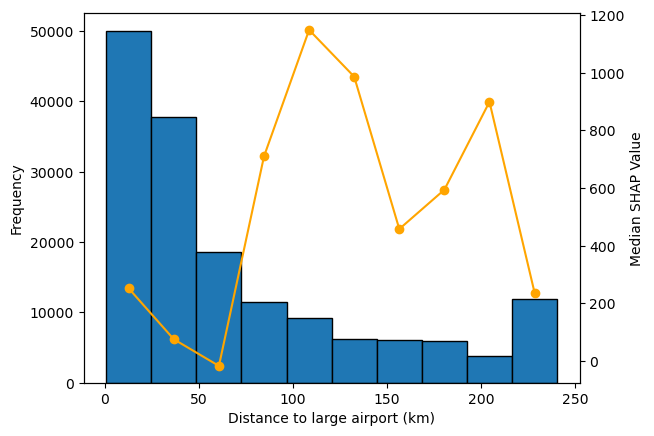

In [23]:
# Distance to large airport univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.dlairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.dlairport >= hist[1][x]) & (xgb_x.dlairport < hist[1][x+1]), 17]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to large airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

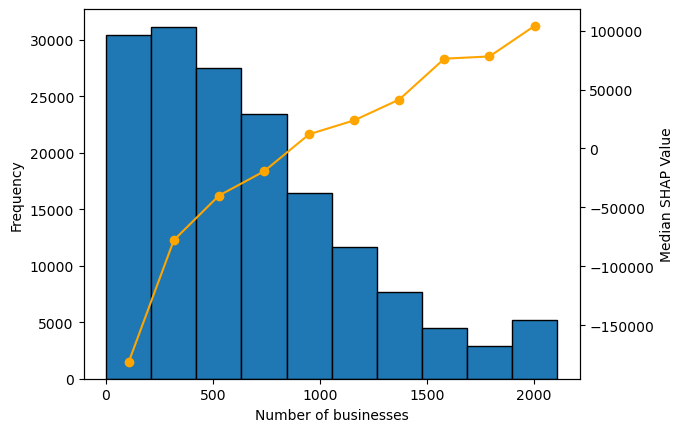

In [24]:
# Number of businesses univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.nobusiness, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.nobusiness >= hist[1][x]) & (xgb_x.nobusiness < hist[1][x+1]), 20]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Number of businesses')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

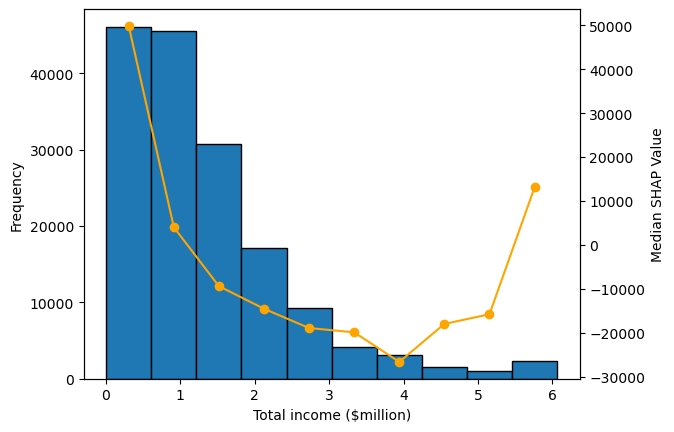

In [40]:
# Total income univariate
fig, ax = plt.subplots()

hist = ax.hist(xgb_x.totalincome, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.median(shap_values_xgb[(xgb_x.totalincome >= hist[1][x]) & (xgb_x.totalincome < hist[1][x+1]), 21]) for x in range(len(hist[1])-1)]
ax.set_xlabel('Total income ($million)')
ax.set_ylabel('Frequency')
ax.set_xticks(ticks = [0,1000000,2000000,3000000,4000000,5000000,6000000], labels = ['0', '1', '2', '3', '4', '5', '6'])
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median SHAP Value')
plt.show()

In [27]:
# # Adjusted income univariate
# fig, ax = plt.subplots()

# hist = ax.hist(xgb_x.adjustedincome, ec = 'black')
# midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
# shaps = [np.median(shap_values_xgb[(xgb_x.adjustedincome >= hist[1][x]) & (xgb_x.adjustedincome < hist[1][x+1]), 22]) for x in range(len(hist[1])-1)]
# ax.set_xlabel('Adjusted income')
# ax.set_ylabel('Frequency')
# ax2 = ax.twinx()
# ax2.plot(midpts, shaps, color = 'orange')
# ax2.scatter(midpts, shaps, color = 'orange')
# ax2.set_ylabel('Median SHAP Value')
# plt.show()

In [203]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([model_xgb.feature_names_in_, model_xgb.feature_importances_]).T.sort_values(by = 1, ascending = False))
#.sort_values(1, ascending = False))
pd.reset_option('display.max_columns')

,0,1
24,California,0.413751
1,bath,0.082211
5,longzip,0.070293
20,totalincome,0.0442
57,Utah,0.029726
27,District of Columbia,0.023596
21,tax_returns,0.021891
48,Ohio,0.021134
18,dshore,0.02043
28,Florida,0.017404


In [29]:
print(np.median(xgb_pred[sold_test.California == 1]),np.median(xgb_pred[sold_test.California == 0]))

699152.75 310260.0


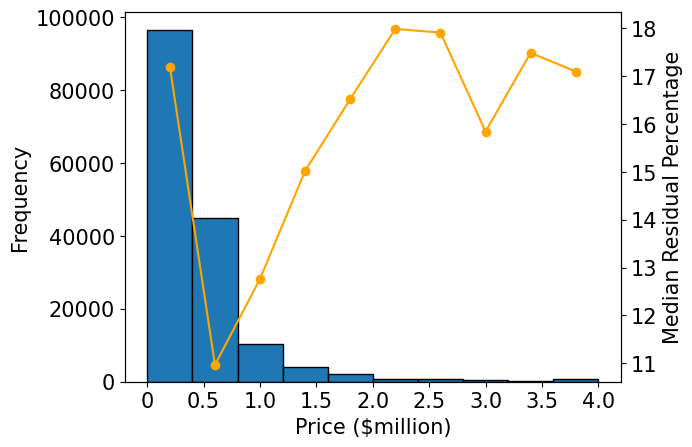

In [ ]:
# XGB %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.price, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [np.abs(percenterror_xgb[(sold_test.price >= hist[1][x]) & (sold_test.price < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Price ($million)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.set_xticks(ticks = [0,500000,1000000,1500000,2000000,2500000,3000000,3500000,4000000], labels = ['0','0.5','1.0','1.5','2.0','2.5','3.0','3.5','4.0'])
ax.tick_params(axis = 'both', labelsize = '15')
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = '15')
ax2.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/error_price.pdf')
plt.show()


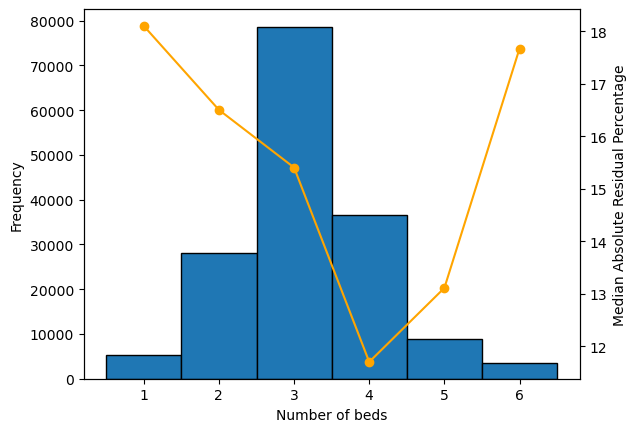

In [ ]:
# XGB bed %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.bed, ec = 'black', bins = np.arange(0.5,7.5))
resids = [(np.abs(percenterror_xgb[sold_test.bed == x])).median() * 100 for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of beds')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), resids, color = 'orange')
ax2.scatter(np.arange(1,7), resids, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

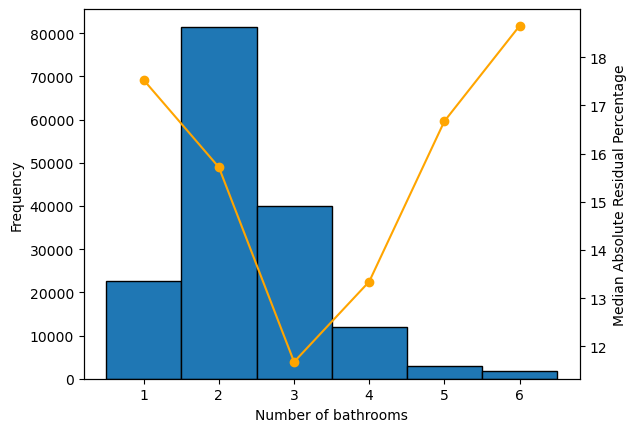

In [ ]:
# XGB bath %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.bath, ec = 'black', bins = np.arange(0.5,7.5))
resids = [(np.abs(percenterror_xgb[sold_test.bath == x])).median() * 100 for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of bathrooms')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), resids, color = 'orange')
ax2.scatter(np.arange(1,7), resids, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

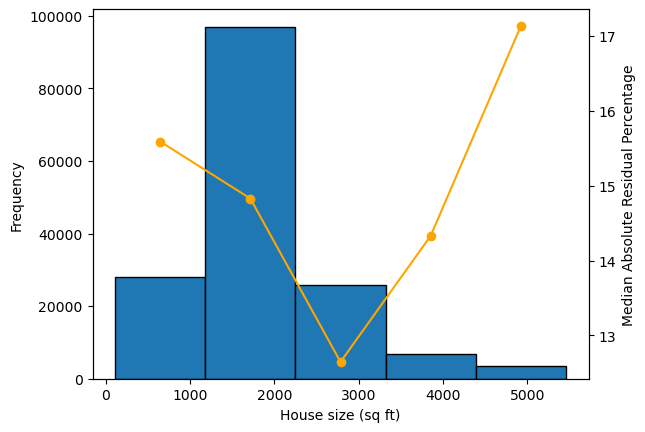

In [16]:
# XGB house size %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.house_size, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.house_size >= hist[1][x]) & (sold_test.house_size < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('House size (sq ft)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

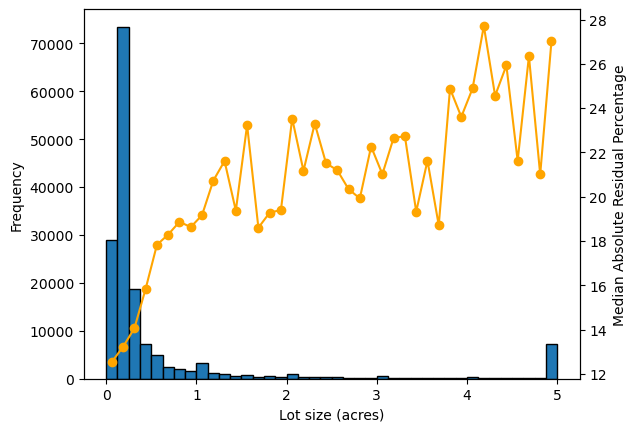

In [59]:
# XGB acre lot %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.acre_lot, ec = 'black', bins = 40)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.acre_lot >= hist[1][x]) & (sold_test.acre_lot < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Lot size (acres)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

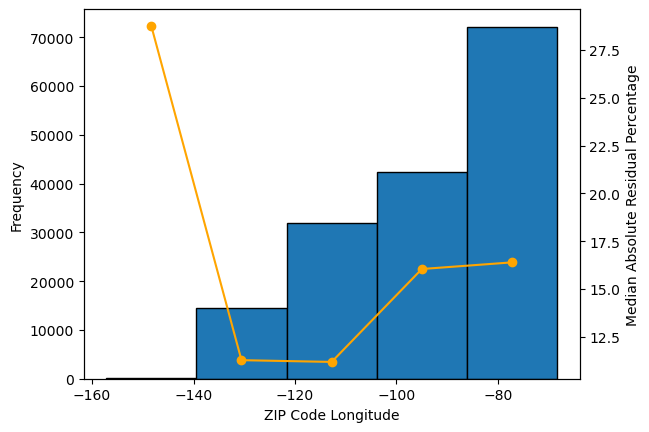

In [22]:
# XGB ZIP long %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.longzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.longzip >= hist[1][x]) & (sold_test.longzip < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Longitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

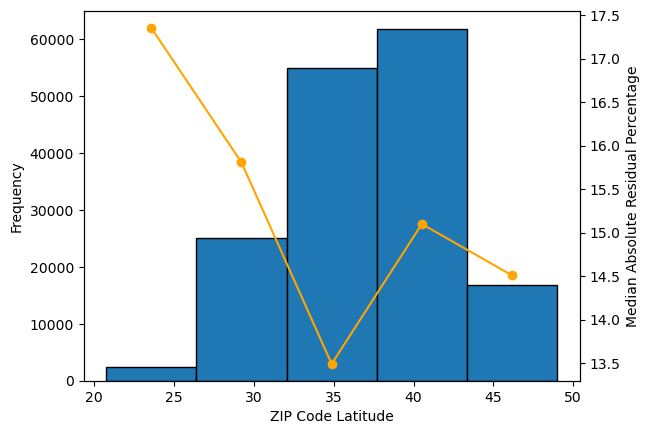

In [23]:
# XGB ZIP lat %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.latzip, ec = 'black', bins = 5)
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.latzip >= hist[1][x]) & (sold_test.latzip < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('ZIP Code Latitude')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

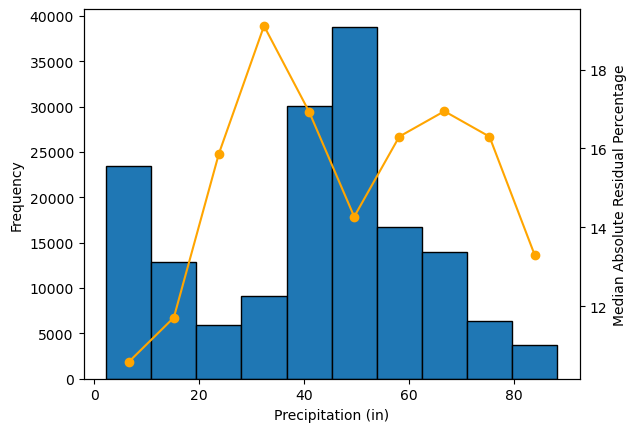

In [25]:
# XGB ZIP lat %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.precipitation, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.precipitation >= hist[1][x]) & (sold_test.precipitation < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Precipitation (in)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

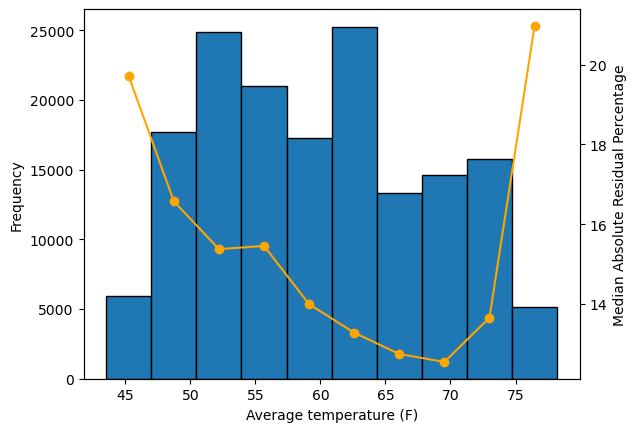

In [27]:
# XGB average temperature %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.avgtemp, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.avgtemp >= hist[1][x]) & (sold_test.avgtemp < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Average temperature (F)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

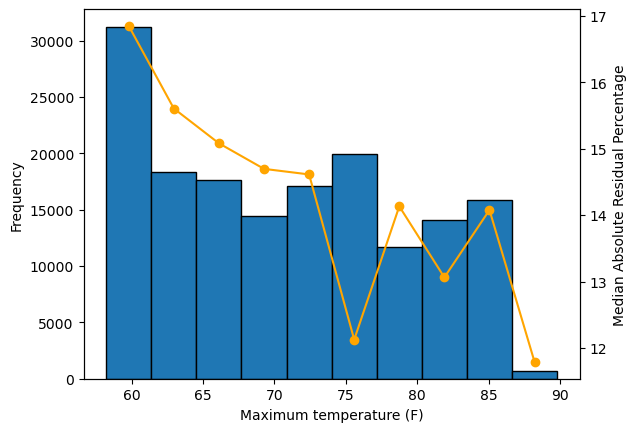

In [28]:
# XGB max temperature %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.maxtemp, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.maxtemp >= hist[1][x]) & (sold_test.maxtemp < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Maximum temperature (F)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

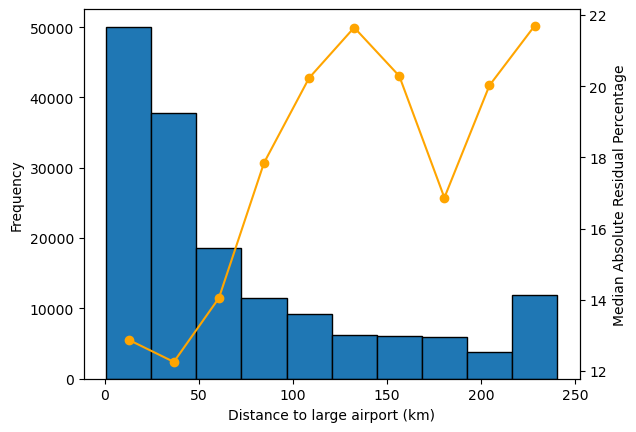

In [ ]:
# XGB d large airport %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.dlairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.dlairport >= hist[1][x]) & (sold_test.dlairport < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to large airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage', fontsize = '15')
plt.show()

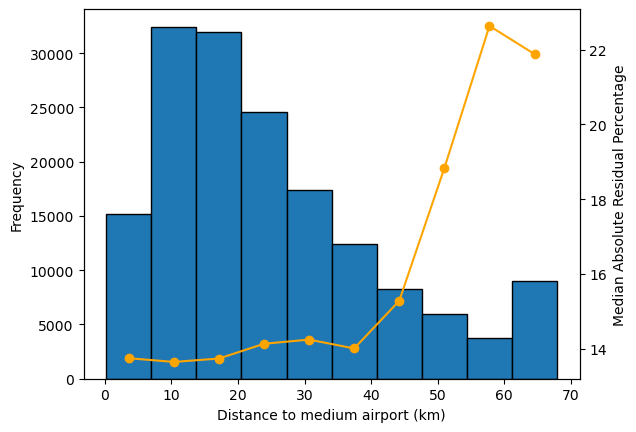

In [ ]:
# XGB d medium airport %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.dmairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.dmairport >= hist[1][x]) & (sold_test.dmairport < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to medium airport (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

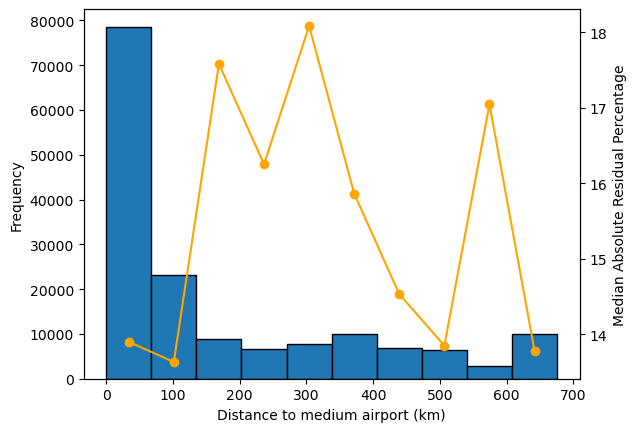

In [ ]:
# XGB d shoreline %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.dshore, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.dshore >= hist[1][x]) & (sold_test.dshore < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to shoreline (km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

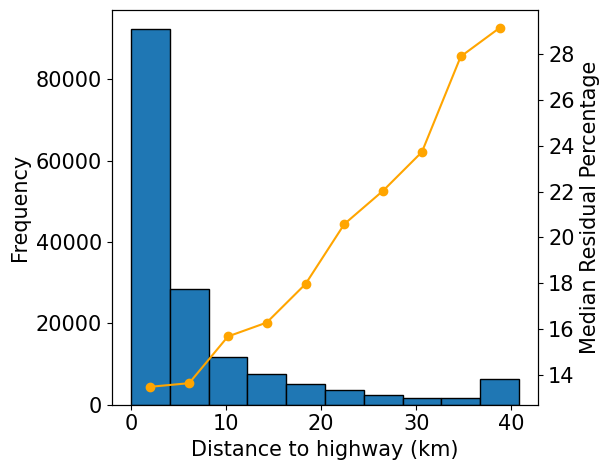

In [193]:
# XGB d highway %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.dhighway, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.dhighway >= hist[1][x]) & (sold_test.dhighway < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to highway (km)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis='both', labelsize = '15')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = '15')
ax2.tick_params(axis='both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/error_dhighway.pdf')
plt.show()

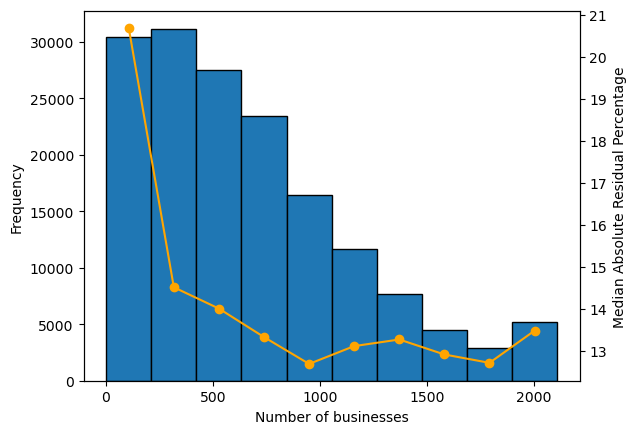

In [ ]:
# XGB no of businesses %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.nobusiness, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.nobusiness >= hist[1][x]) & (sold_test.nobusiness < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Number of businesses')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

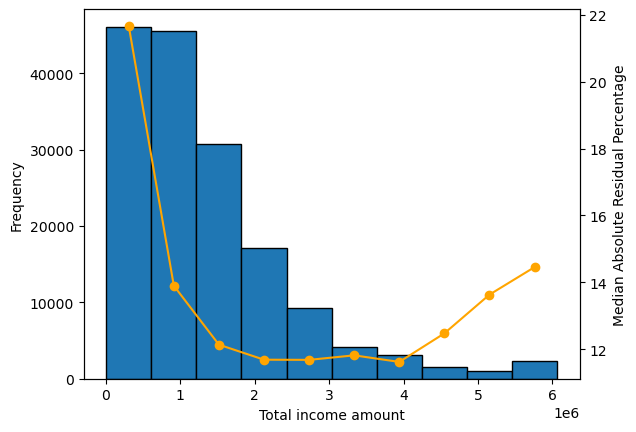

In [37]:
# XGB income %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.totalincome, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.totalincome >= hist[1][x]) & (sold_test.totalincome < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Total income amount')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

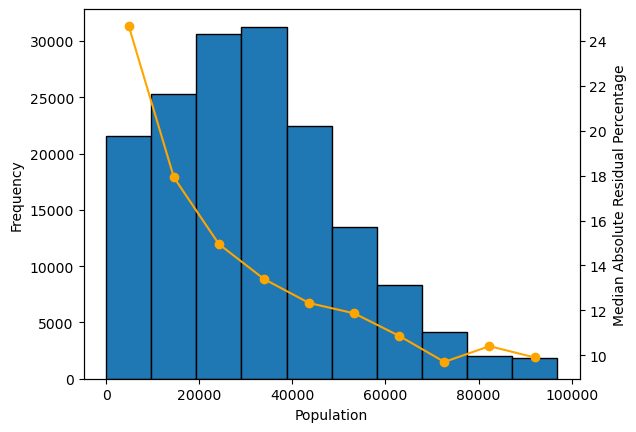

In [38]:
# XGB population %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.population, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.population >= hist[1][x]) & (sold_test.population < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Population')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

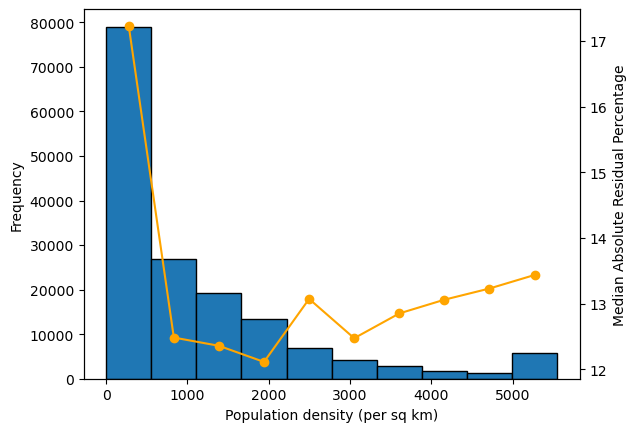

In [39]:
# XGB population density %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test.density, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
shaps = [np.abs(percenterror_xgb[(sold_test.density >= hist[1][x]) & (sold_test.density < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Population density (per sq km)')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(midpts, shaps, color = 'orange')
ax2.scatter(midpts, shaps, color = 'orange')
ax2.set_ylabel('Median Absolute Residual Percentage')
plt.show()

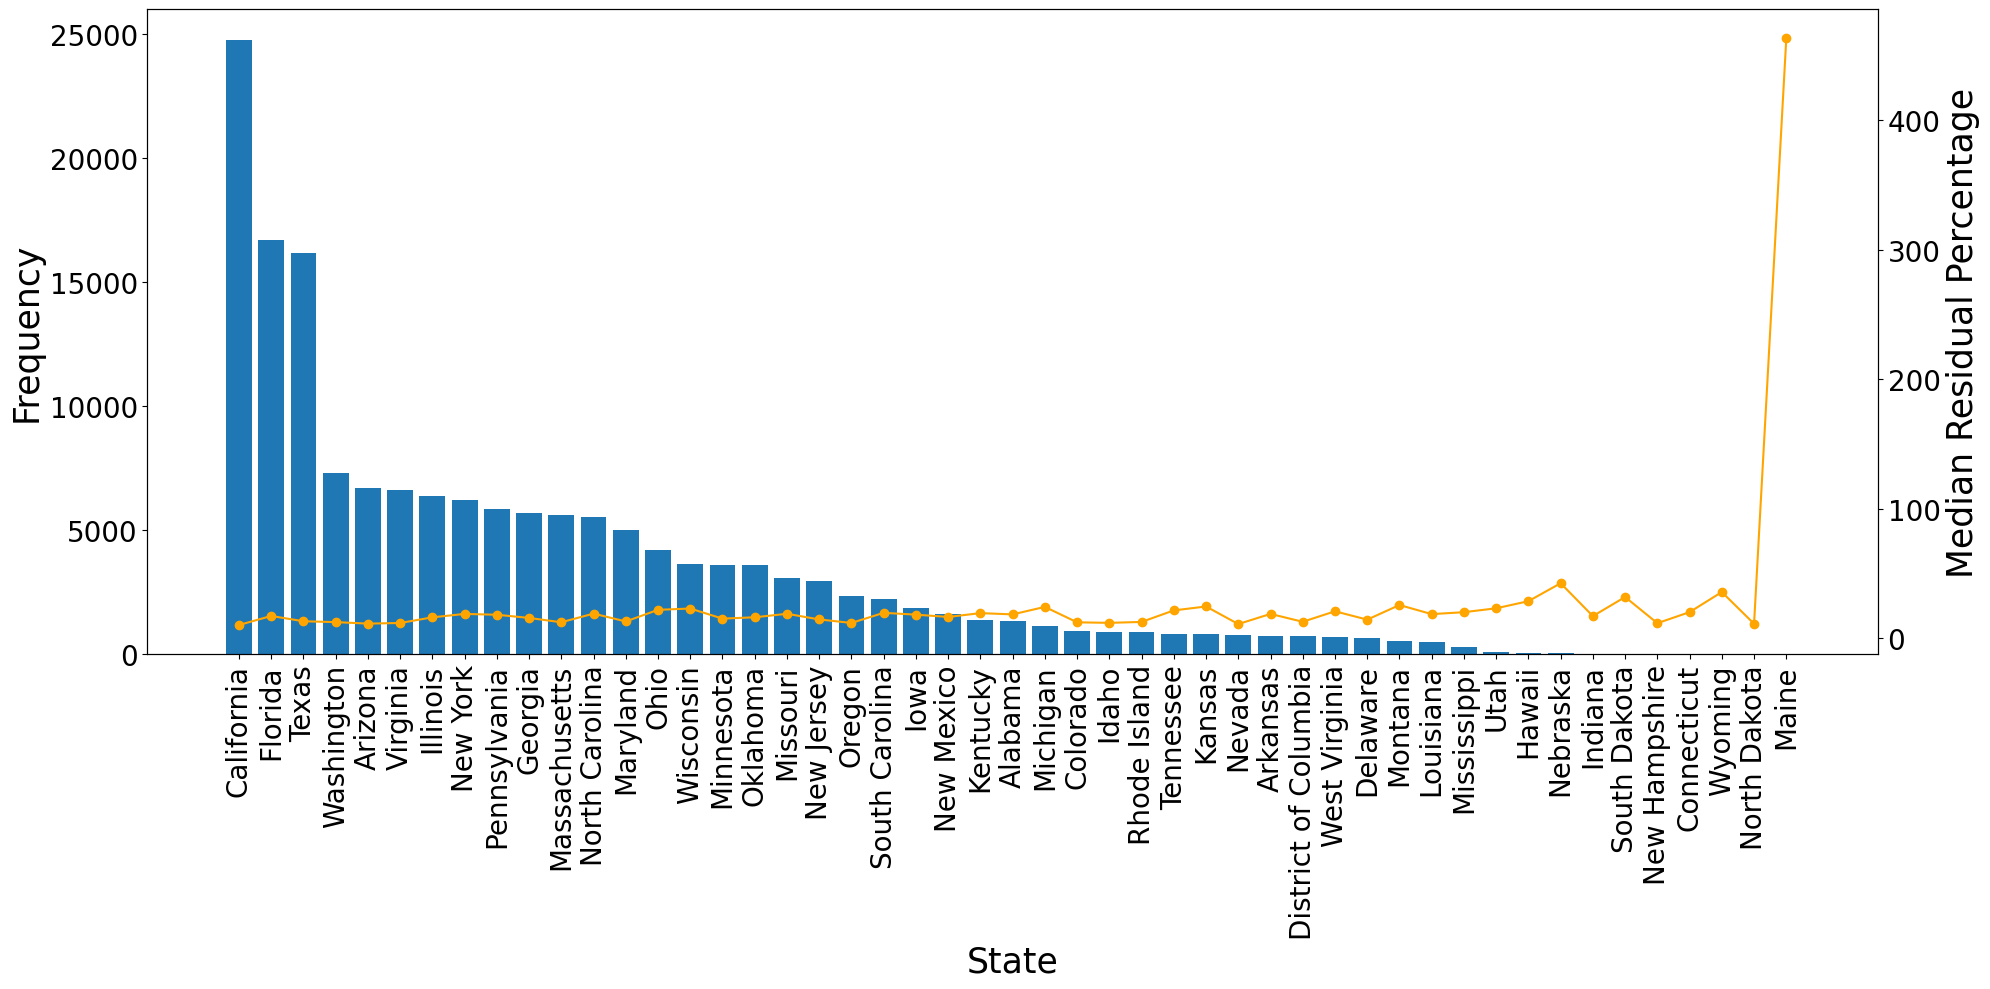

In [226]:
# XGB states %age error
fig, ax = plt.subplots(figsize=(20,10))

states = sold_test.groupby('state').describe()['price'].sort_values(by = 'count', ascending = False).index.tolist()
freq = [len(sold_test[sold_test['state'] == st]) for st in states]
resids = [np.abs(percenterror_xgb[sold_test.state == st]).median() * 100 for st in states]

ax.bar(states, freq)
ax.tick_params(axis='both', labelsize = '20')
ax.set_xlabel('State', fontsize = 25)
ax.set_ylabel('Frequency', fontsize = 25)
plt.xticks(rotation = 90)
ax2 = ax.twinx()
ax2.tick_params(axis='both', labelsize = '20')
ax2.plot(states, resids, color = 'orange')
ax2.scatter(states, resids, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = 25)
# ax2.set_yticks(ticks = [200000,400000,600000,800000,1000000], labels = [0.2,0.4,0.6,0.8,1.0])
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/error_states.pdf')
plt.show()

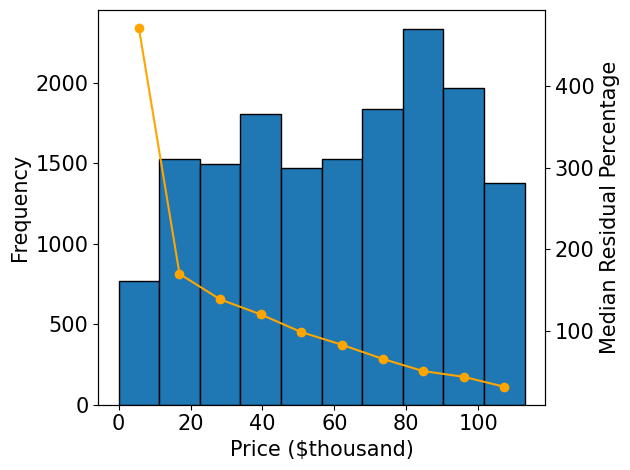

In [228]:
# XGB %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test[sold_test.price <= sold_test.price.quantile(0.1)].price, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [np.abs(percenterror_xgb[(sold_test.price >= hist[1][x]) & (sold_test.price < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Price ($thousand)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis = 'both', labelsize = '15')
ax.set_xticks(ticks = [0,20000,40000,60000,80000,100000], labels = ['0','20','40','60','80','100'])
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = '15')
ax2.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/error_pricebottom10.pdf')
plt.show()

In [227]:
resids

[10.360517710099687,
 17.348057112068965,
 13.25809659090909,
 12.595892857142857,
 11.43914880952381,
 11.91675203003337,
 16.28796746171967,
 18.918167656485675,
 18.280622909698995,
 15.817047438162547,
 12.47735,
 19.156196512744415,
 13.108579684374305,
 22.07302273133262,
 23.077089041095892,
 15.280461289222375,
 16.328920261387054,
 19.012124877008855,
 14.667375635599209,
 11.94876168224299,
 19.765055600214364,
 18.347690118694793,
 16.56854208354177,
 19.542585666023164,
 18.55298681296843,
 24.3387865761391,
 12.440473684210525,
 12.0315450310559,
 12.737469545379,
 21.630212122590034,
 24.660914683612763,
 11.093104166666667,
 18.915634164222876,
 12.849936317321689,
 20.95176083397646,
 14.499910201149424,
 25.785564965694686,
 18.75719865395403,
 20.259303681344697,
 23.25336956521739,
 28.745653688813945,
 42.59328814338236,
 17.228252751572327,
 31.960937499999996,
 11.7626298643344,
 20.300426348766127,
 35.79967621127002,
 11.296260107816712,
 462.934140625]

In [229]:
prices

[471.69136597938143,
 169.90343372134106,
 138.6208099048443,
 120.17362413194444,
 98.43626488095238,
 82.91306423611111,
 65.62990506329113,
 50.61016700563204,
 43.590347492615464,
 31.36815406976744]

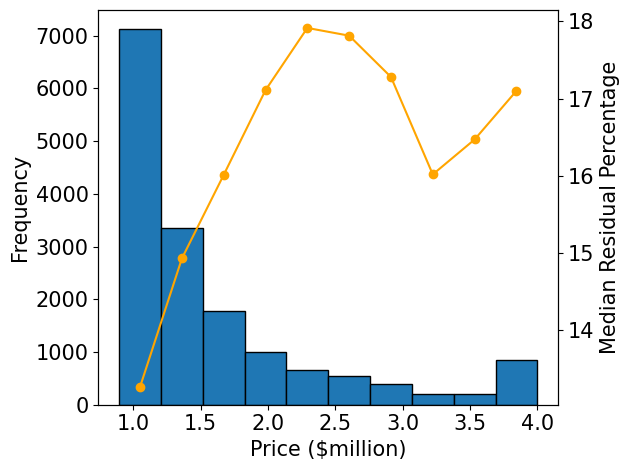

In [202]:
# XGB %age error univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_test[sold_test.price >= sold_test.price.quantile(0.9)].price, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [np.abs(percenterror_xgb[(sold_test.price >= hist[1][x]) & (sold_test.price < hist[1][x+1])]).median() * 100 for x in range(len(hist[1])-1)]
ax.set_xlabel('Price ($million)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis = 'both', labelsize = '15')
ax.set_xticks(ticks = [1000000,1500000,2000000,2500000,3000000,3500000,4000000], labels = ['1.0','1.5','2.0','2.5','3.0','3.5','4.0'])
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange')
ax2.set_ylabel('Median Residual Percentage', fontsize = '15')
ax2.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/error_pricetop10.pdf')
plt.show()

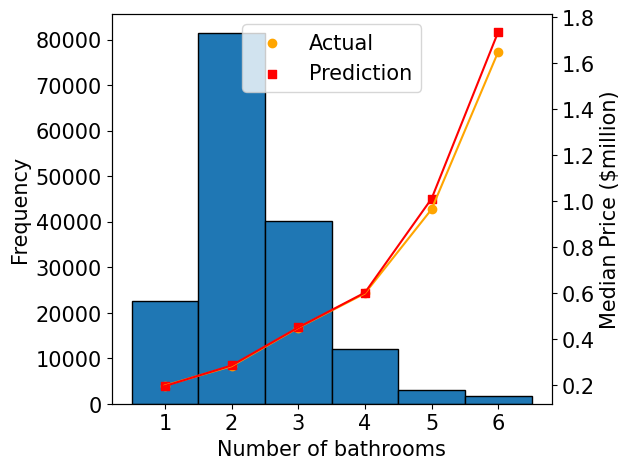

In [ ]:
# Bath price/pred univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_xgb.bath, ec = 'black', bins = np.arange(0.5,7.5))
prices = [sold_xgb[sold_xgb.bath == x].price.median() for x in np.arange(1,7)]
preds = [sold_xgb[sold_xgb.bath == x].pred.median() for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of bathrooms', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis='both', labelsize = '15')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), prices, color = 'orange')
ax2.scatter(np.arange(1,7), prices, color = 'orange', label = 'Actual')
ax2.plot(np.arange(1,7), preds, color = 'red')
ax2.scatter(np.arange(1,7), preds, color = 'red', label = 'Prediction', marker = 's')
ax2.set_ylabel('Median Price ($million)', fontsize = '15')
ax2.legend(loc = 'upper center', fontsize = '15')
ax2.set_yticks(ticks = [200000,400000,600000,800000,1000000,1200000,1400000,1600000,1800000], labels = [0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8])
ax2.tick_params(axis='both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/pricepred_bathroom.pdf')
plt.show()

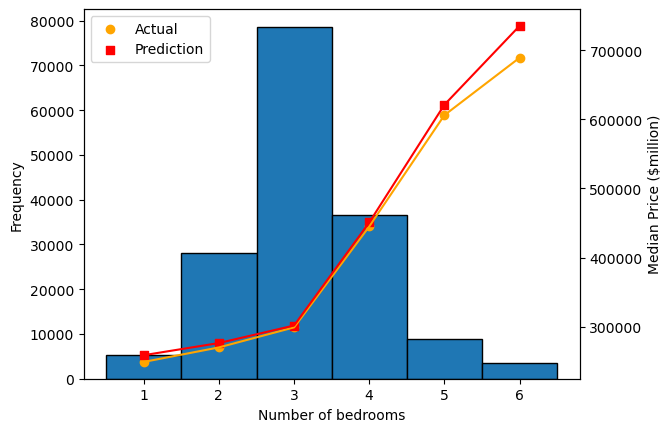

In [206]:
# Bed price/pred univariate
fig, ax = plt.subplots()

hist = ax.hist(sold_xgb.bed, ec = 'black', bins = np.arange(0.5,7.5))
prices = [sold_xgb[sold_xgb.bed == x].price.median() for x in np.arange(1,7)]
preds = [sold_xgb[sold_xgb.bed == x].pred.median() for x in np.arange(1,7)]
ax.set_xticks(ticks = np.arange(0,7), labels = np.arange(0,7))
ax.set_xlabel('Number of bedrooms')
ax.set_ylabel('Frequency')
ax2 = ax.twinx()
ax2.plot(np.arange(1,7), prices, color = 'orange')
ax2.scatter(np.arange(1,7), prices, color = 'orange', label = 'Actual')
ax2.plot(np.arange(1,7), preds, color = 'red')
ax2.scatter(np.arange(1,7), preds, color = 'red', label = 'Prediction', marker = 's')
ax2.set_ylabel('Median Price ($million)')
ax2.legend()
# ax2.set_yticks(ticks = [200000,400000,600000,800000,1000000,1200000,1400000,1600000], labels = [0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6])
plt.show()

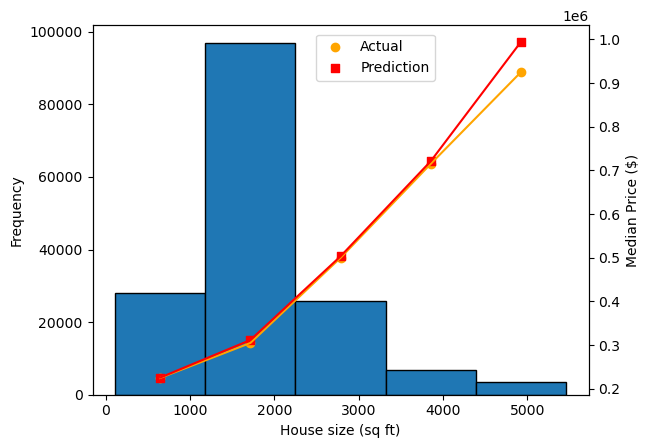

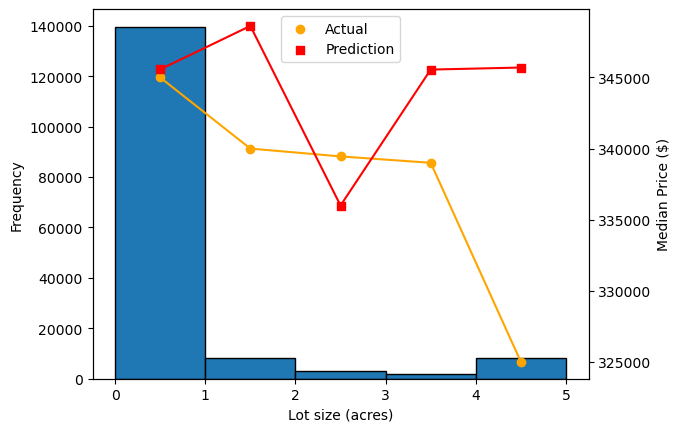

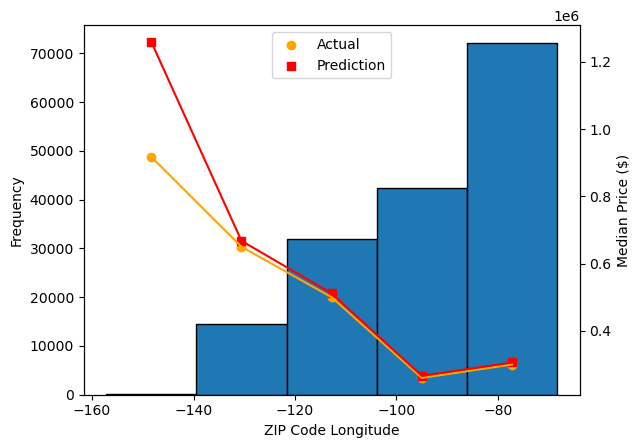

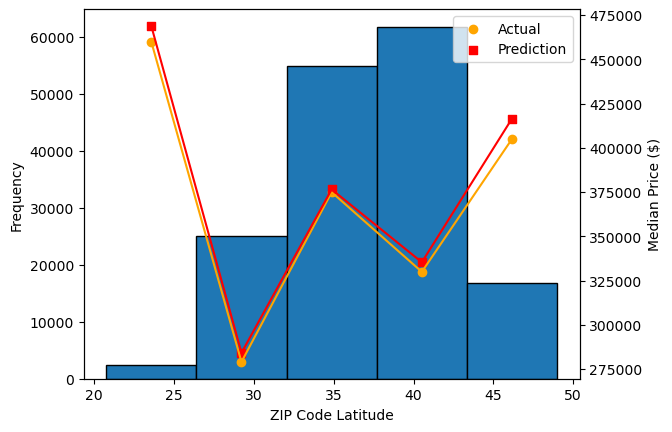

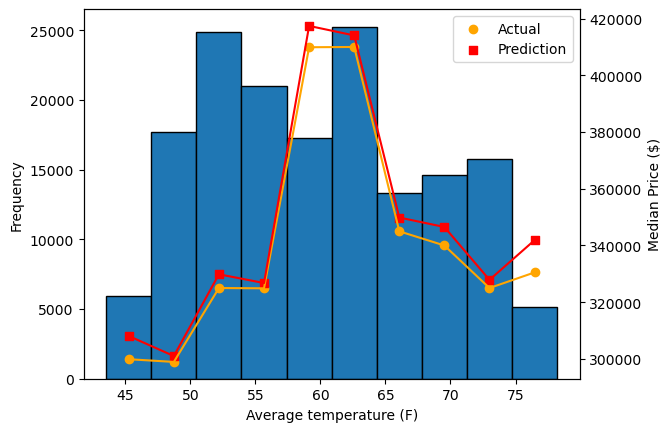

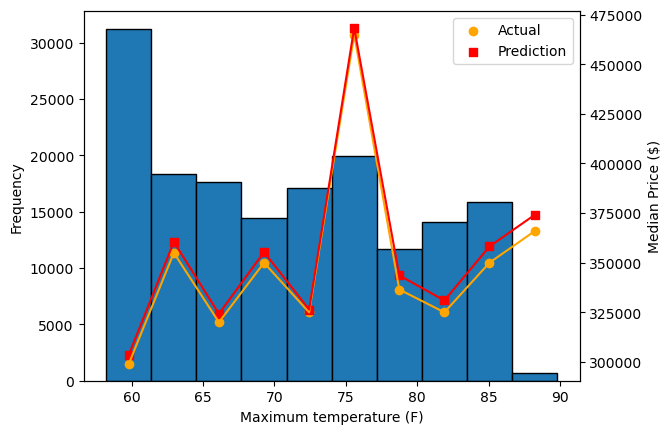

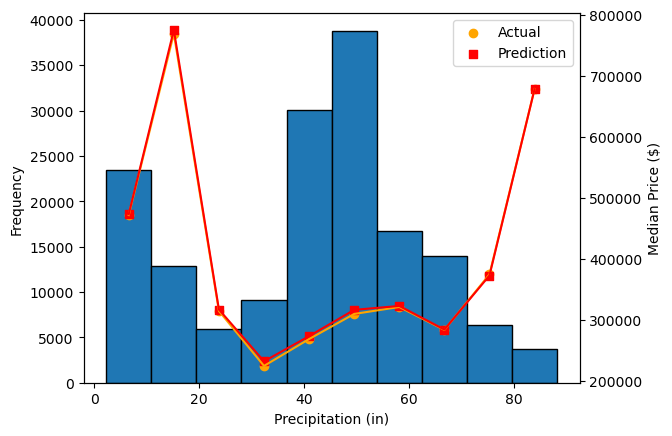

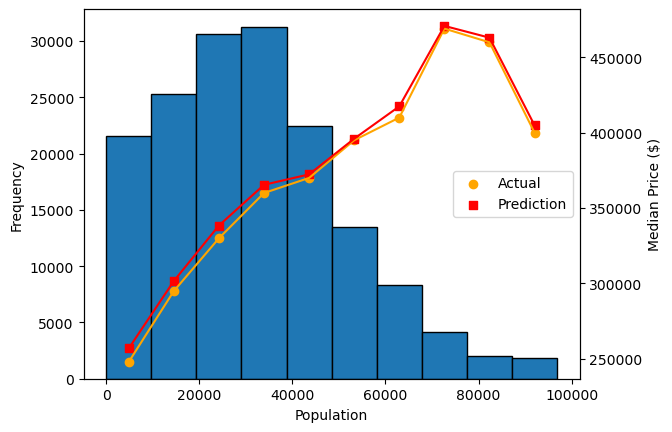

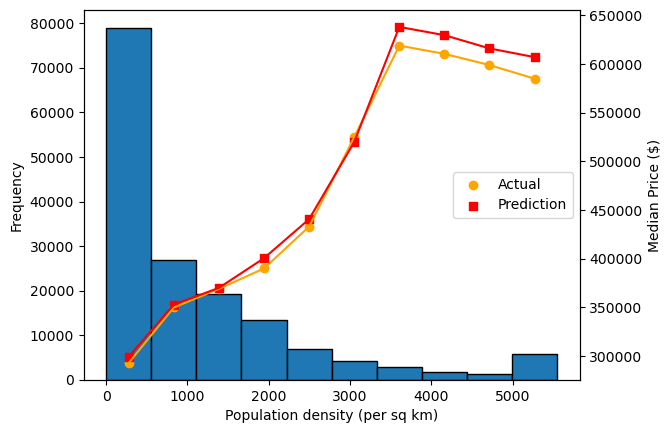

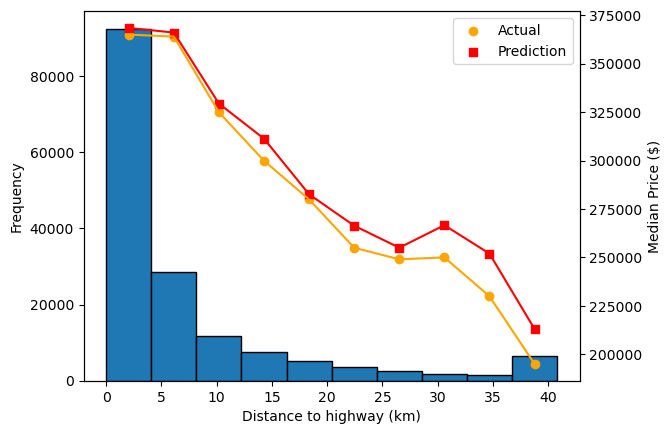

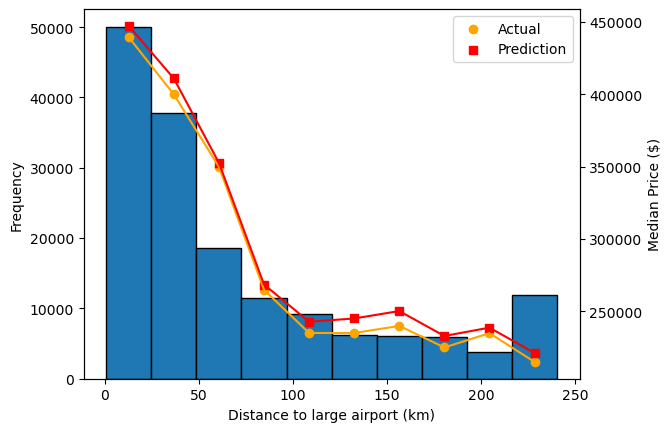

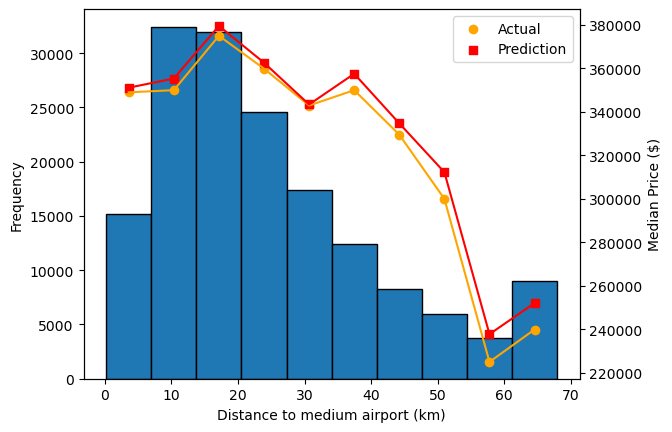

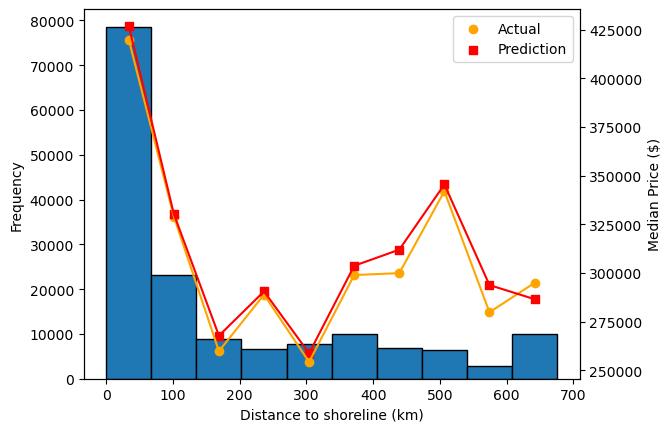

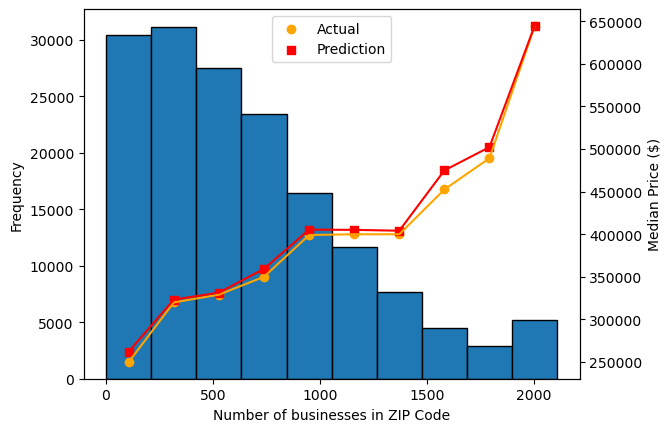

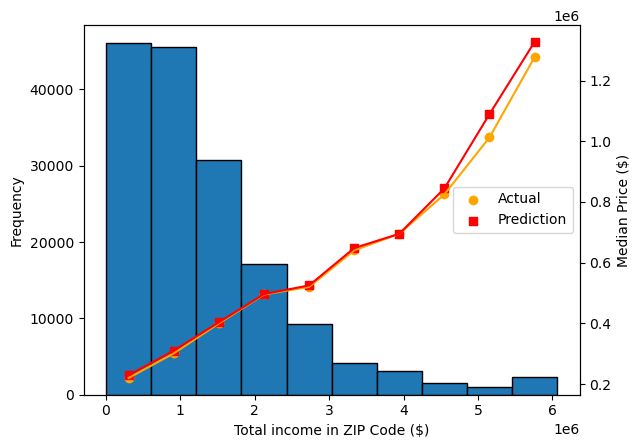

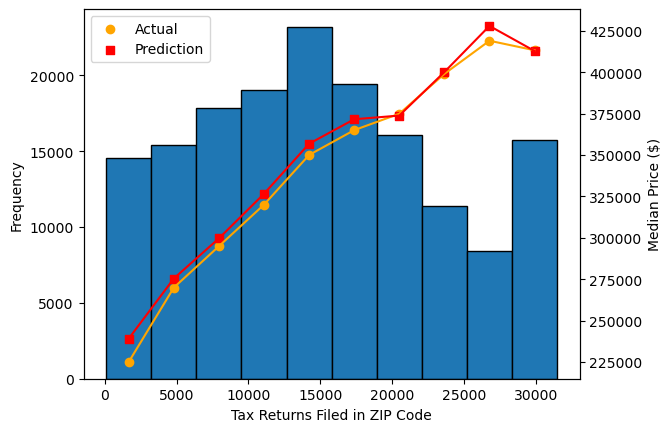

In [146]:
# House size price/pred univariate
plt_pricepred('house_size', 'House size (sq ft)', bin_no = 5, leg_pos = (0.45,0.85))
plt_pricepred('acre_lot', 'Lot size (acres)', bin_no = 5, leg_pos = 'upper center')
plt_pricepred('longzip', 'ZIP Code Longitude', bin_no = 5, leg_pos = 'upper center')
plt_pricepred('latzip', 'ZIP Code Latitude', bin_no = 5, leg_pos = 'upper right')
plt_pricepred('avgtemp', 'Average temperature (F)')
plt_pricepred('maxtemp', 'Maximum temperature (F)')
plt_pricepred('precipitation', 'Precipitation (in)')
plt_pricepred('population', 'Population', leg_pos = 'center right')
plt_pricepred('density', 'Population density (per sq km)', leg_pos = 'center right')
plt_pricepred('dhighway', 'Distance to highway (km)')
plt_pricepred('dlairport', 'Distance to large airport (km)')
plt_pricepred('dmairport', 'Distance to medium airport (km)')
plt_pricepred('dshore', 'Distance to shoreline (km)')
plt_pricepred('nobusiness', 'Number of businesses in ZIP Code', leg_pos = 'upper center')
plt_pricepred('totalincome', 'Total income in ZIP Code ($)', leg_pos = 'center right')
plt_pricepred('tax_returns', 'Tax Returns Filed in ZIP Code', leg_pos = 'upper left')

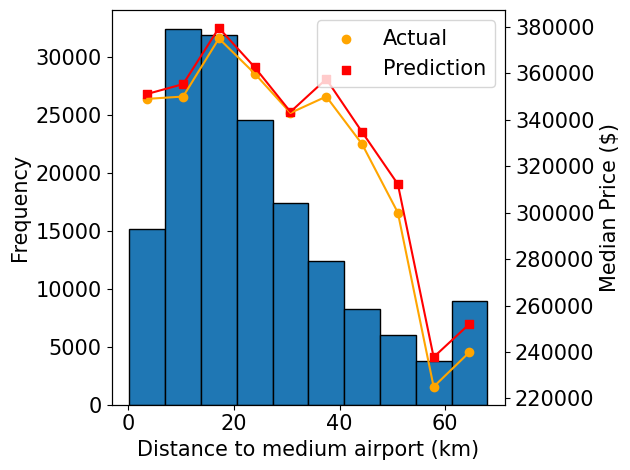

In [188]:
fig, ax = plt.subplots()

hist = ax.hist(sold_xgb.dmairport, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [sold_xgb[(sold_xgb.dmairport >= hist[1][x]) & (sold_xgb.dmairport < hist[1][x+1])].price.median() for x in range(len(hist[1])-1)]
preds = [sold_xgb[(sold_xgb.dmairport >= hist[1][x]) & (sold_xgb.dmairport < hist[1][x+1])].pred.median() for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to medium airport (km)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis='both', labelsize = '15')
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange', label = 'Actual')
ax2.plot(midpts, preds, color = 'red')
ax2.scatter(midpts, preds, color = 'red', label = 'Prediction', marker = 's')
ax2.set_ylabel('Median Price ($)', fontsize = '15')
ax2.legend(loc = 'upper right', fontsize = '15')
ax2.tick_params(axis='both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/pricepred_dmairport.pdf')
plt.show()

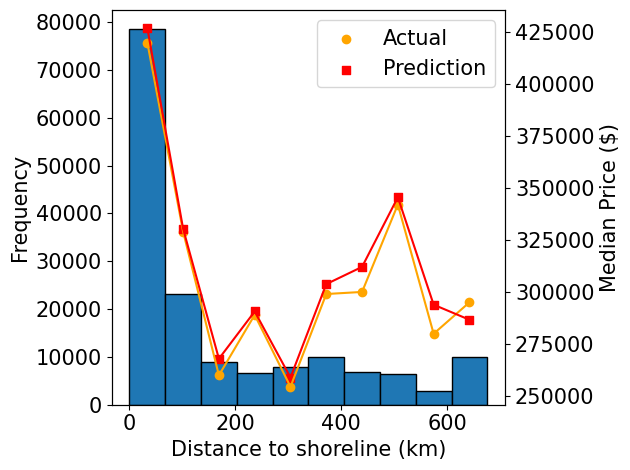

In [224]:
fig, ax = plt.subplots()

hist = ax.hist(sold_xgb.dshore, ec = 'black')
midpts = [((hist[1][x] + hist[1][x+1])/2) for x in range(len(hist[1])-1)]
prices = [sold_xgb[(sold_xgb.dshore >= hist[1][x]) & (sold_xgb.dshore < hist[1][x+1])].price.median() for x in range(len(hist[1])-1)]
preds = [sold_xgb[(sold_xgb.dshore >= hist[1][x]) & (sold_xgb.dshore < hist[1][x+1])].pred.median() for x in range(len(hist[1])-1)]
ax.set_xlabel('Distance to shoreline (km)', fontsize = '15')
ax.set_ylabel('Frequency', fontsize = '15')
ax.tick_params(axis='both', labelsize = '15')
# ax.set_xticks(ticks = [0,1000000,2000000,3000000,4000000,5000000,6000000], labels = [0,1,2,3,4,5,6])
ax2 = ax.twinx()
ax2.plot(midpts, prices, color = 'orange')
ax2.scatter(midpts, prices, color = 'orange', label = 'Actual')
ax2.plot(midpts, preds, color = 'red')
ax2.scatter(midpts, preds, color = 'red', label = 'Prediction', marker = 's')
ax2.set_ylabel('Median Price ($)', fontsize = '15')
ax2.legend(loc = 'upper right', fontsize = '15')
ax2.tick_params(axis='both', labelsize = '15')
# ax2.set_yticks(ticks = [400000,600000,800000,1000000,1200000], labels = [0.4,0.6,0.8,1.0,1.2])
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/pricepred_dshore.pdf')
plt.show()

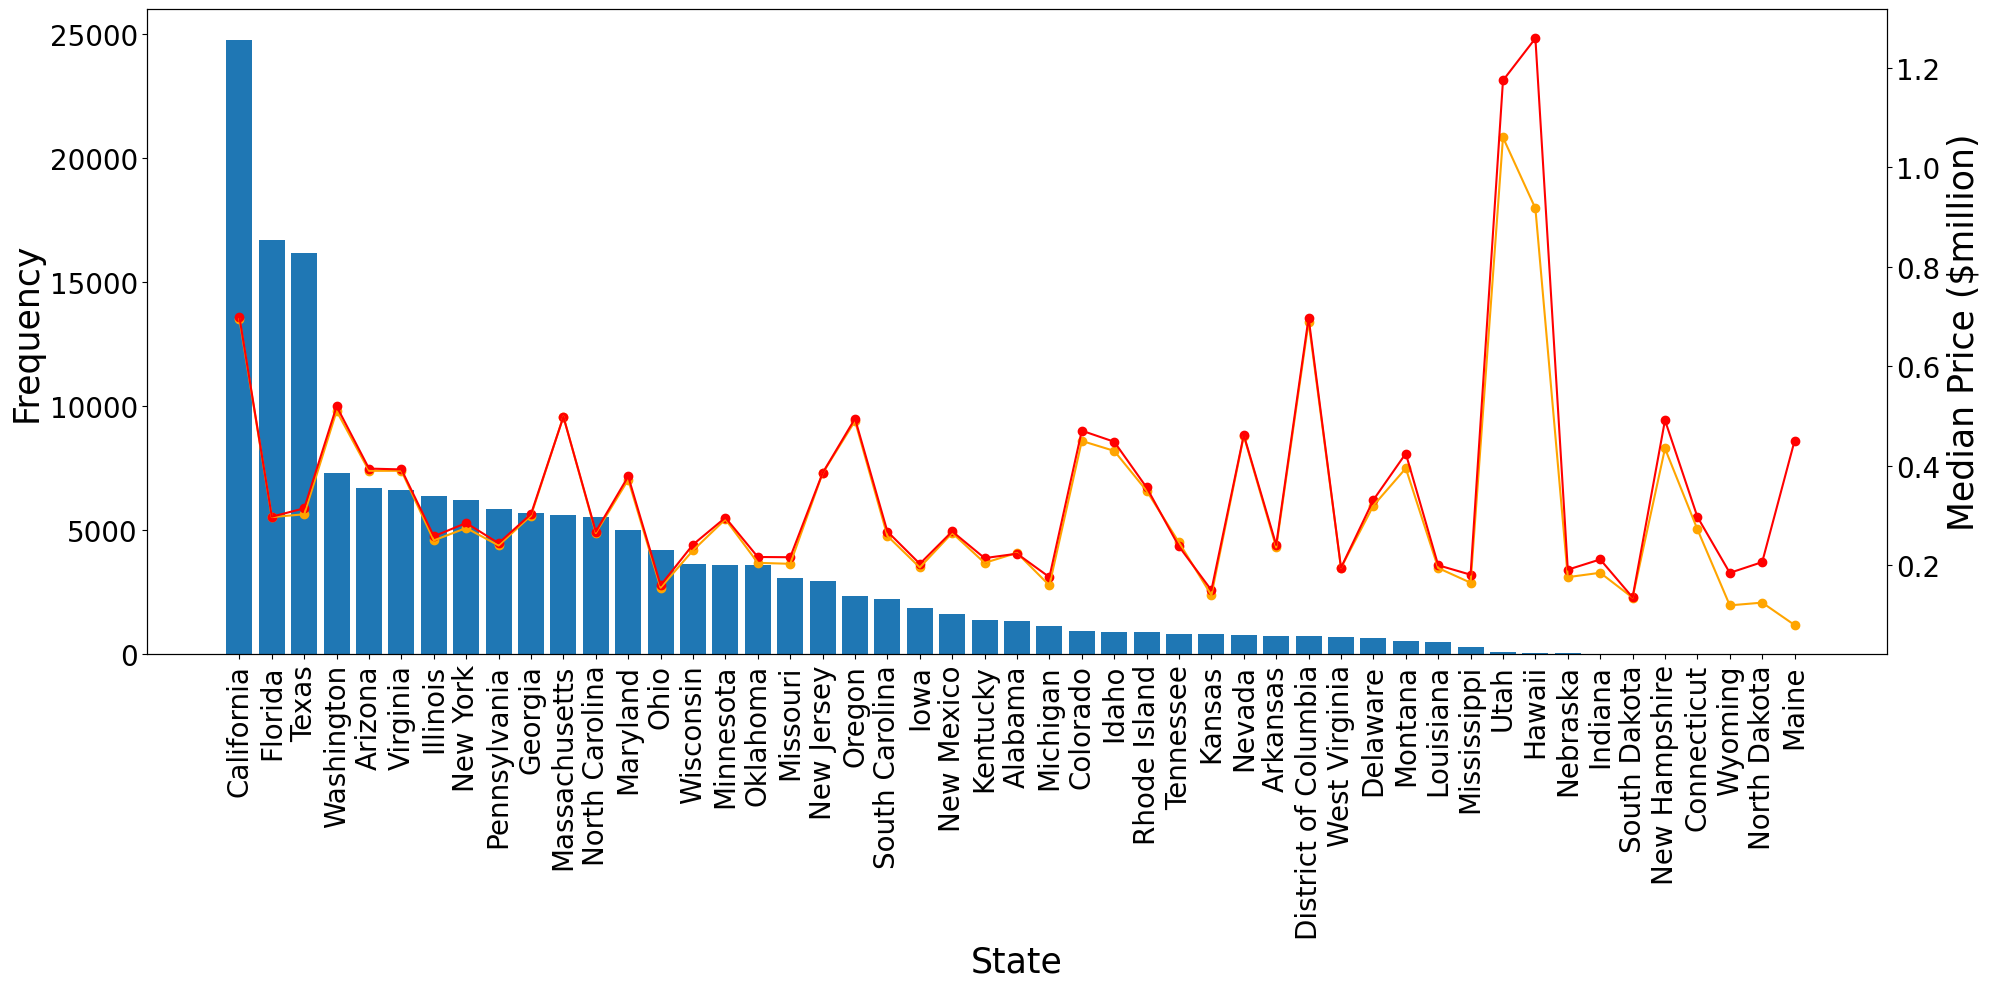

In [201]:
# XGB states %age error
fig, ax = plt.subplots(figsize=(20,10))

states = sold_xgb.groupby('state').describe()['price'].sort_values(by = 'count', ascending = False).index.tolist()
freq = [len(sold_xgb[sold_xgb['state'] == st]) for st in states]
prices = [sold_xgb[sold_xgb.state == st].price.median() for st in states]
preds = [sold_xgb[sold_xgb.state == st].pred.median() for st in states]

ax.bar(states, freq)
ax.tick_params(axis='both', labelsize = '20')
ax.set_xlabel('State', fontsize = 25)
ax.set_ylabel('Frequency', fontsize = 25)
plt.xticks(rotation = 90)
ax2 = ax.twinx()
ax2.tick_params(axis='both', labelsize = '20')
ax2.plot(states, prices, color = 'orange')
ax2.scatter(states, prices, color = 'orange', label = 'Actual')
ax2.plot(states, preds, color = 'red')
ax2.scatter(states, preds, color = 'red', label = 'Prediction')
ax2.set_ylabel('Median Price ($million)', fontsize = 25)
ax2.set_yticks(ticks = [200000,400000,600000,800000,1000000,1200000], labels = [0.2,0.4,0.6,0.8,1.0,1.2])
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/pricepred_states.pdf')
plt.show()

In [164]:
df = pd.DataFrame([states, resids, freq]).T
df = df.rename(columns = {0:'state', 1:'Median absolute residual', 2:'Frequency'})

# source: https://gist.github.com/rogerallen/1583593
us_state_to_abbrev = pd.DataFrame([{
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "American Samoa": "AS",
    "Guam": "GU",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "United States Minor Outlying Islands": "UM",
    "Virgin Islands, U.S.": "VI",
}])

us_state_to_abbrev = us_state_to_abbrev.T.reset_index()
us_state_to_abbrev = us_state_to_abbrev.rename(columns = {'index':'state', 0:'code'})
df = pd.merge(df, us_state_to_abbrev, on = 'state')
df = df.drop([48])

In [165]:
def plot_heatmap(df, var): 
    # plotting the heatmap by states
    fig = go.Figure(data=go.Choropleth(
        locations=df['code'], # Spatial coordinates
        z = df[var].astype(float), # Data to be color-coded
        locationmode = 'USA-states', # set of locations match entries in `locations`
        colorscale = 'Reds',
        colorbar_title = var,
        text = df['state']
    ))

    fig.update_layout(
        title_text = var + ' by state<br>(Hover over the states for details)',
        geo_scope='usa', # limit map scope to USA
    )

    fig.show()

In [167]:
plot_heatmap(df, 'Median absolute residual')

In [168]:
plot_heatmap(df, 'Frequency')

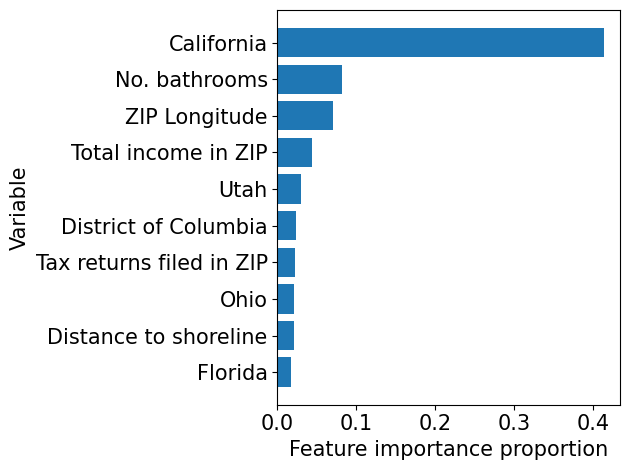

In [160]:
sorted_idx = model_xgb.feature_importances_.argsort()
# plt.figure(figsize=(10,15))
plt.barh(model_xgb.feature_names_in_[sorted_idx][-10:], model_xgb.feature_importances_[sorted_idx][-10:])
plt.yticks(ticks = model_xgb.feature_names_in_[sorted_idx][-10:], labels = ['Florida', 'Distance to shoreline', 'Ohio', 'Tax returns filed in ZIP', 'District of Columbia', 'Utah', 'Total income in ZIP', 'ZIP Longitude', 'No. bathrooms', 'California'])
plt.xlabel('Feature importance proportion', fontsize = '15')
plt.ylabel('Variable', fontsize = '15')
plt.tick_params(axis='both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/fimp_xgb.pdf')
plt.show()

In [209]:
states_important = ['California', 'Utah', 'District of Columbia', 'Ohio', 'Florida']
for state in states_important:
    print(state, 'Median in:', sold_xgb[sold_xgb[state] == 1].pred.median(), 'Median out:', sold_xgb[sold_xgb[state] == 0].pred.median())

California Median in: 699152.78125 Median out: 310260.015625
Utah Median in: 1174633.75 Median out: 346370.0
District of Columbia Median in: 697419.375 Median out: 345553.3125
Ohio Median in: 159744.46875 Median out: 353036.0
Florida Median in: 297687.84375 Median out: 354618.65625


RandomForestRegressor

R^2 0.8414886857031137
RMSE 195028.1939290348
MAE 92208.18860224377
Positive residuals: 72211
Negative residuals: 88804
Average positive residual: 99653.20043503631
Average negative residual: -86163.61993686428
Average percentage error: 58.33605219340674


Text(0, 0.5, 'Predicted')

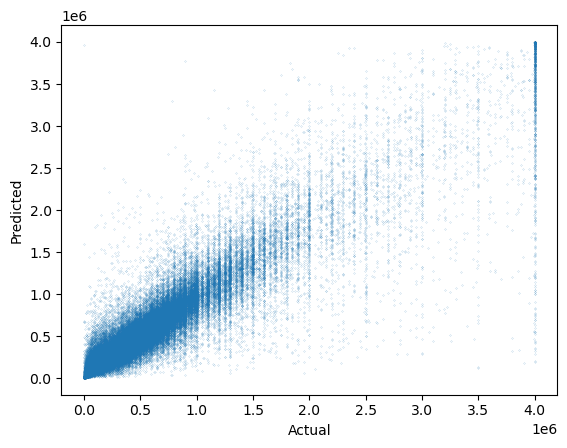

In [8]:
rf_x = sold_test[['bed', 'bath', 'acre_lot', 'house_size', 'latzip', 'longzip', 'cityfreq', 'streetfreq', 'brokerfreq', 'precipitation', 'maxtemp', 'avgtemp', 'po_box', 'population', 'density', 'dhighway', 'dlairport', 'dmairport', 'dshore', 'nobusiness', 'totalincome', 'adjustedincome', 'tax_returns', 'California']]
rf_y = sold_test['price']
rf_pred = model_rf.predict(rf_x)

resids_rf = rf_y - rf_pred
percenterror_rf = (rf_y - rf_pred) / rf_y
print('R^2', model_rf.score(rf_x, rf_y))
print('RMSE', root_mean_squared_error(rf_y, rf_pred))
print('MAE', mean_absolute_error(rf_y, rf_pred))
print('Positive residuals:', len(resids_rf[resids_rf > 0]))
print('Negative residuals:', len(resids_rf[resids_rf < 0]))
print('Average positive residual:', np.mean(resids_rf[resids_rf > 0]))
print('Average negative residual:', np.mean(resids_rf[resids_rf < 0]))
print('Average percentage error:', np.mean(abs(percenterror_rf)))
plt.scatter(rf_y, rf_pred, s = 0.01)
plt.xlabel('Actual')
plt.ylabel('Predicted')

In [ ]:
explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf.shap_values(rf_x)

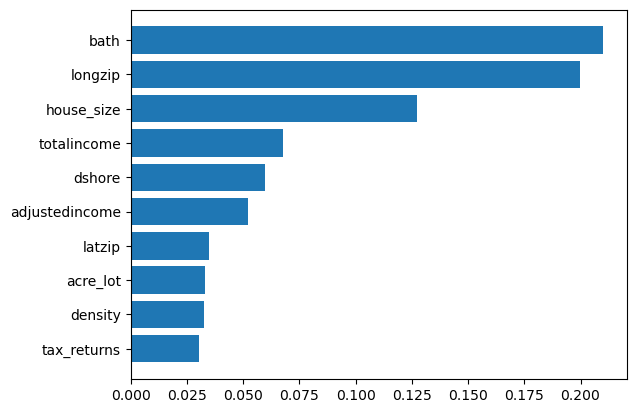

In [102]:
sorted_idx = model_rf.feature_importances_.argsort()
# plt.figure(figsize=(10,15))
plt.barh(model_rf.feature_names_in_[sorted_idx][-10:], model_rf.feature_importances_[sorted_idx][-10:])
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/fimp_rf.pdf')
plt.show()

In [38]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(pd.DataFrame([model_rf.feature_names_in_, model_rf.feature_importances_]).T.sort_values(1, ascending = False))
pd.reset_option('display.max_columns')

,0,1
1,bath,0.21005
5,longzip,0.199813
3,house_size,0.127449
20,totalincome,0.067646
18,dshore,0.05982
21,adjustedincome,0.052297
4,latzip,0.034757
2,acre_lot,0.032913
14,density,0.032726
22,tax_returns,0.030156
